<a href="https://colab.research.google.com/github/kiki286/dream-classifier/blob/main/notebooks/03_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dream Clustering — Notebook 03: Clustering

This notebook takes the feature matrices created in **Notebook 02 (Feature Extraction)** and performs **unsupervised clustering** to discover emergent dream themes.

Two parallel pipelines are provided:
1. **TF‑IDF → TruncatedSVD → KMeans**
2. **Sentence Embeddings → PCA → KMeans**

The notebook also:
- Explores k selection via inertia (elbow) and silhouette scores
- Generates 2D projections for visualization
- Saves cluster labels and helpful summaries (top terms & exemplar dreams)


In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Step 1: Imports and Configuration

In [41]:
import os
import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# ML / clustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Plotting
import matplotlib.pyplot as plt

# Paths
DATA_DIR = Path("/content/drive/MyDrive/dream-clustering/data/processed")
FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Config
USE_TFIDF = True          # Set to False to use sentence embeddings pipeline
K_DEFAULT = 4             # Default number of clusters for KMeans
MIN_WORDS = 10            # Must match Notebook 02 filter to keep alignment

print(f"Using {'TF-IDF' if USE_TFIDF else 'Embeddings'} pipeline by default.")


Using TF-IDF pipeline by default.


## Step 2: Load Cleaned Data and Features

Reload the cleaned CSV and re-apply the same length filter (`MIN_WORDS`) used in Notebook 02.  
This must match the feature extraction notebook to ensure row order alignment.


In [42]:
# Load cleaned dreams
df = pd.read_csv(DATA_DIR / "cleaned_dreams.csv")
df['text_clean'] = df['text_clean'].fillna('')
df = df[df['text_clean'].str.split().str.len() > MIN_WORDS].reset_index(drop=True)
print(f"Dream rows after filter: {len(df)}")


# Load features based on pipeline choice
X = None
feature_type = None

if USE_TFIDF and (DATA_DIR / "tfidf_matrix.npz").exists():
    from scipy.sparse import load_npz
    X = load_npz(DATA_DIR / "tfidf_matrix.npz")
    feature_type = "tfidf"
elif (DATA_DIR / "embeddings.npy").exists():
    X = np.load(DATA_DIR / "embeddings.npy")
    feature_type = "embeddings"
    USE_TFIDF = False
else:
    raise FileNotFoundError("No feature matrix found. Expected tfidf_matrix.npz or embeddings.npy in data/processed/")

print(f"Loaded feature matrix type: {feature_type}")
try:
    nrows = X.shape[0]
except Exception:
    nrows = X.shape[0]
print("Features rows:", nrows)
assert len(df) == nrows, "Row-count mismatch between cleaned data and features. Ensure Notebook 02 filter/order matches."


Dream rows after filter: 22019
Loaded feature matrix type: tfidf
Features rows: 22019


## Step 3: Pick a Reasonable k (KMeans)

Scan a small range of cluster counts and compute:
- **Inertia** (within-cluster sum of squares): lower is better, look for an elbow
- **Silhouette score**: higher is better (range -1 to 1)

> Note: Silhouette on very high dimensions can be noisy — we first reduce dimensionality lightly for speed/stability.


In [43]:
# Light reduction for k scanning (keeps alignment but speeds metrics)
if feature_type == 'tfidf':
    reducer_kscan = TruncatedSVD(n_components=min(100, X.shape[1]-1), random_state=42)
    X_scan = reducer_kscan.fit_transform(X)
else:
    reducer_kscan = PCA(n_components=min(100, X.shape[1]), random_state=42)
    X_scan = reducer_kscan.fit_transform(X)

ks = list(range(2, 11))
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scan)
    inertias.append(km.inertia_)
    try:
        sil = silhouette_score(X_scan, labels, metric='euclidean')
    except Exception:
        sil = np.nan
    sil_scores.append(sil)

# Plot elbow (inertia)
plt.figure()
plt.plot(ks, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method (Inertia vs k)')
plt.grid(True)
plt.savefig(FIG_DIR / f"elbow_{feature_type}.png", dpi=150)
plt.show()

# Plot silhouette
plt.figure()
plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette vs k')
plt.grid(True)
plt.savefig(FIG_DIR / f"silhouette_{feature_type}.png", dpi=150)
plt.show()

print("k candidates:", ks)
print("Inertias:", inertias)
print("Silhouette:", sil_scores)


KeyboardInterrupt: 

## Step 4: Final Dimensionality Reduction & KMeans
Perform a more principled reduction and fit KMeans with the chosen `K_DEFAULT`.

- **TF‑IDF:** use `TruncatedSVD` (LSA) to ~100 dims
- **Embeddings:** use `PCA` to ~50 dims



In [54]:
K = 4 # Educated guess based on the elbow graph without overfitting

if feature_type == 'tfidf':
    reducer = TruncatedSVD(n_components=100, random_state=42)
    X_reduced = reducer.fit_transform(X)
else:
    reducer = PCA(n_components=min(50, X.shape[1]), random_state=42)
    X_reduced = reducer.fit_transform(X)

km_final = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = km_final.fit_predict(X_reduced)

df_clusters = df.copy()
df_clusters['cluster'] = labels
print(df_clusters['cluster'].value_counts().sort_index())

# Save labels and model
df_clusters.to_csv(DATA_DIR / f"dreams_clustered_{feature_type}_k{K}.csv", index=False)
with open(DATA_DIR / f"kmeans_{feature_type}_k{K}.pkl", 'wb') as f:
    pickle.dump(km_final, f)


cluster
0     5279
1    10912
2     4630
3     1198
Name: count, dtype: int64


## Step 5: Interpret Clusters



### 5A. Top Terms per Cluster (TF‑IDF)
For TF‑IDF features, we compute the mean TF‑IDF of all documents within each cluster and report the top words.  
(This is more robust than reading KMeans centroids after reduction.)


In [55]:
def top_terms_tfidf(X_sparse, labels, feature_names, topn=15):
    tops = {}
    for c in sorted(np.unique(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            tops[c] = []
            continue
        # average TF-IDF per term within the cluster
        mean_vec = X_sparse[idx].mean(axis=0)  # 1 x n_features sparse matrix
        mean_arr = np.asarray(mean_vec).ravel()
        top_idx = np.argsort(mean_arr)[::-1][:topn]
        tops[c] = [feature_names[i] for i in top_idx]
    return tops

if feature_type == 'tfidf':
    from scipy.sparse import load_npz
    from sklearn.feature_extraction.text import TfidfVectorizer
    # Reload features and names (feature names saved in Notebook 02)
    X_tfidf = X  # same object
    feat_path = DATA_DIR / "tfidf_features.txt"
    if feat_path.exists():
        with open(feat_path, 'r', encoding='utf-8') as f:
            feature_names = [line.strip() for line in f if line.strip()]
    else:
        feature_names = [f"f{i}" for i in range(X_tfidf.shape[1])]

    top_terms = top_terms_tfidf(X_tfidf, labels, np.array(feature_names), topn=15)
    for c, words in top_terms.items():
        print(f"Cluster {c}:", ", ".join(words))


Cluster 0: say, says, man, like, woman, room, look, don, feel, want, comes, walk, people, house, think
Cluster 1: dream, house, friend, people, like, room, remember, saw, school, went, going, time, came, water, man
Cluster 2: said, like, went, didn, going, just, got, came, told, know, looked, room, asked, kind, really
Cluster 3: car, driving, drive, road, going, got, house, street, seat, like, went, saw, man, home, friend


### 5B. Exemplar Dreams per Cluster (Embeddings)

For embedding features, we can identify representative examples per cluster.  
Compute the cluster centroid in reduced space and select nearest dreams as exemplars.


In [56]:
def exemplar_indices(X_space, labels, k=3):
    idxs_per_cluster = {}
    for c in sorted(np.unique(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            idxs_per_cluster[c] = []
            continue
        center = X_space[idx].mean(axis=0, keepdims=True)
        # Euclidean distance in the current space
        dists = np.linalg.norm(X_space[idx] - center, axis=1)
        order = np.argsort(dists)
        idxs_per_cluster[c] = idx[order[:k]].tolist()
    return idxs_per_cluster

exemplars = exemplar_indices(X_reduced, labels, k=3)
for c, idxs in exemplars.items():
    print(f"\nCluster {c} exemplars:")
    for ix in idxs:
        # Print a short preview of the dream text
        txt = df_clusters.loc[ix, 'text_clean']
        preview = (txt[:140] + '...') if len(txt) > 140 else txt
        print('-', preview)



Cluster 0 exemplars:
- Digging A Hole At Fishing Haven I'm on Fishing Haven property, on the 15-Mile property on the hill side of the driveway. I'm back in the woo...
- I am seated either in the driver's seat, or in the back seat behind it. Dwight was driving and he gets out to adjust something and doesn't p...
- Ellie is going to do a strip tease in a contest. She's the first one up. She is 200 lbs. and confident. She gets up on the platform, which i...

Cluster 1 exemplars:
- Something about distant then, and confused or burned or disfigured now.
- A helicopter was rising in the distance. Something was hanging from it that was related to something of mine.
- I was telling someone that spirit is more important than matter.

Cluster 2 exemplars:
- I was sitting on the roof drawing trapezoids and parallelograms. Actually they were rectangles but with the vanishing points and points of v...
- Bob and Diane and we were discussing our experiences coming across the country. They had had so

## Step 6: 2D Projection for Visualization

Project the reduced features to **2D** for plotting.

- Default: **PCA → 2D**
- Optional: **UMAP** for better local structure but takes longer


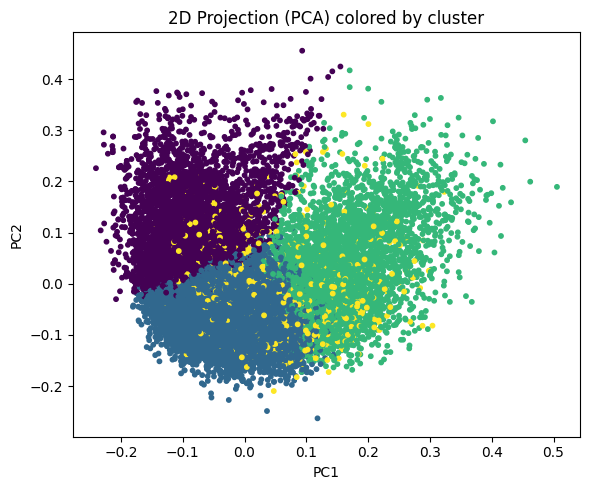

Saved 2D PCA scatter to: report/figures/scatter_2d_pca_tfidf_k4.png


In [57]:
# 2D projection
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_reduced)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:,0], X_2d[:,1], s=10, c=labels)
plt.title('2D Projection (PCA) colored by cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(FIG_DIR / f"scatter_2d_pca_{feature_type}_k{K}.png", dpi=150)
plt.show()

print("Saved 2D PCA scatter to:", FIG_DIR / f"scatter_2d_pca_{feature_type}_k{K}.png")


### (Optional) Use UMAP for 2D Projection



In [ ]:
!pip install umap-learn
import umap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


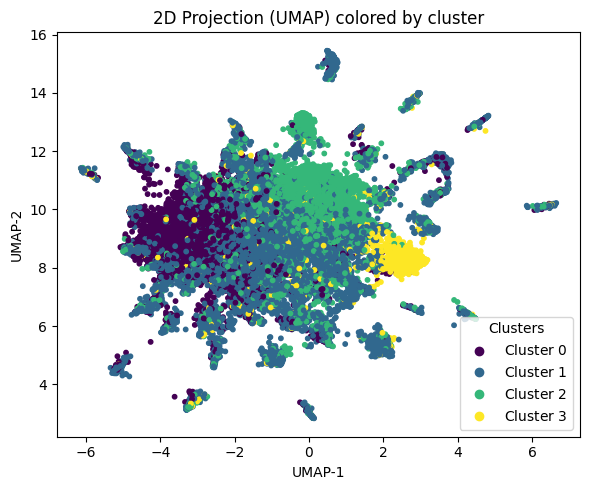

In [59]:
umap_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_2d.fit_transform(X_reduced)

plt.figure(figsize=(6,5))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], s=10, c=labels, cmap='viridis') # Use a colormap
plt.title('2D Projection (UMAP) colored by cluster')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

# Add a legend
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
for text in legend.get_texts():
    text.set_text(f"Cluster {text.get_text()}")

plt.tight_layout()
plt.savefig(FIG_DIR / f"scatter_2d_umap_{feature_type}_k{K}.png", dpi=150)
plt.show()

## Step 7: Save Human-Readable Summaries

Save:
- Cluster label assignments (already saved with `dreams_clustered_*.csv`)
- Optional text files listing top terms (TF‑IDF) and exemplars per cluster


In [53]:
# Save top terms (TF-IDF)
if feature_type == 'tfidf':
    terms_out = FIG_DIR / f"cluster_top_terms_{feature_type}_k{K}.txt"
    with open(terms_out, 'w', encoding='utf-8') as f:
        for c in sorted(top_terms.keys()):
            f.write(f"Cluster {c}: {', '.join(top_terms[c])}\n")
    print("Saved top terms:", terms_out)

# Save exemplars
ex_out = FIG_DIR / f"cluster_exemplars_{feature_type}_k{K}.txt"
with open(ex_out, 'w', encoding='utf-8') as f:
    for c in sorted(exemplars.keys()):
        f.write(f"\nCluster {c}\n")
        for ix in exemplars[c]:
            txt = df_clusters.loc[ix, 'text_clean']
            preview = (txt[:200] + '...') if len(txt) > 200 else txt
            f.write(f"- {preview}\n")
print("Saved exemplar previews:", ex_out)


Saved top terms: report/figures/cluster_top_terms_tfidf_k3.txt
Saved exemplar previews: report/figures/cluster_exemplars_tfidf_k3.txt


## Summary

- Scanned **k** with elbow and silhouette (saved plots)
- Reduced dimensionality (TF‑IDF → SVD or Embeddings → PCA)
- Clustered with KMeans , saved labels and model
- Interpreted clusters via top terms (TF‑IDF) and exemplar dreams
- Created 2D projections for reports


### Data Analysis

*   The configuration was successfully updated to use the both sentence embeddings pipeline and TF-IDF.
*   Dimensionality reduction for clustering was performed using PCA with 50 components.
*   KMeans clustering with 4 clusters was applied to the PCA-reduced embeddings and with TF-IDF.
*   Cluster labels were assigned to the dataframe, and the distribution of dreams across clusters was printed.
*   Exemplar dreams were successfully extracted and saved to a text file for manual interpretation.
*   2D projections of the embeddings were generated using both PCA and UMAP and saved as scatter plots, colored by cluster.



### Insights or Next Steps

*   From a cursory glance of the exemplars the sentence embedding seems to produce more distinct clusters.
*   Maybe more stopwords should be included to remove words like "dream" from influencing cluster generation, but it seems like clusters are picking up on self-referential or meta dreams as well, which seems important.
*   Further interpretation of the clusters can be done by manually reviewing the exemplar dreams in the saved text file to identify common themes, emotions, or narratives within each cluster before the next notebook.
